# Gate B5 — доказательный аудит и benchmark protocol

Gate B5 заморозил train-only benchmark поверх **911 origins**, 98 points, 14 profiles и 4 зон. В плане ровно **65 outer folds**: 11 rolling-origin, 42 spatio-temporal leave-profile-out и 12 leave-zone-out; к ним относятся 195 forward-only inner folds.

Это протокол `train_only_internal_research`. Исторический validation, раскрытый T1 test и новый holdout не загружались. Notebook читает только сохранённые machine artifacts и ничего не переобучает.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
while not (root / 'pyproject.toml').is_file():
    root = root.parent
artifact = root / 'artifacts' / 'model_selection' / 't1_b5_evidence_v1'
split_root = root / 'artifacts' / 'splits' / 't1_train_benchmark_v1'
report = json.loads((artifact / 'gate_b5_report.json').read_text(encoding='utf-8'))
validation = json.loads((artifact / 'validation_report.json').read_text(encoding='utf-8'))
contracts = pd.read_csv(split_root / 'fold_contracts.csv')
atlas = pd.read_csv(artifact / 'error_atlas.csv')
dependence = pd.read_csv(artifact / 'residual_dependence.csv')
units = pd.read_csv(artifact / 'independent_units.csv')
learning = pd.read_csv(artifact / 'learning_curves.csv')
methods = json.loads((artifact / 'method_cards.json').read_text(encoding='utf-8'))
{'gate_status': report['status'], 'validation': validation['summary'], 'plan_sha256': report['benchmark']['plan_sha256']}

{'gate_status': 'PASS_PROTOCOL_FROZEN',
 'validation': {'checks': 20, 'failed': 0, 'passed': 20},
 'plan_sha256': 'd143f1c057f176f49c78d9433e4305557339854d1c1faaad77bc356aca8fd926'}

## Замороженная геометрия folds

In [2]:
outer = contracts.loc[contracts['level'].eq('outer')]
inner = contracts.loc[contracts['level'].eq('inner')]
summary = outer.groupby('design').agg(
    folds=('fold_id', 'nunique'),
    train_rows_min=('train_rows', 'min'),
    train_rows_max=('train_rows', 'max'),
    validation_rows=('validation_rows', 'sum'),
)
assert len(outer) == 65 and len(inner) == 195
assert (pd.to_datetime(contracts['train_target_date_max']) < pd.to_datetime(contracts['validation_target_date_min'])).all()
summary

,folds,train_rows_min,train_rows_max,validation_rows
design,,,,
rolling_origin,11,316,823,595
spatiotemporal_leave_profile_out,42,558,786,266
spatiotemporal_leave_zone_out,12,333,749,266


## Реальные независимые единицы и residual dependence

In [3]:
units.groupby('design').agg(
    origins=('origins', 'max'),
    temporal_units=('temporal_units', 'max'),
    profiles=('profile_units', 'max'),
    zones=('zone_units', 'max'),
    point_trajectories=('point_trajectories', 'max'),
)

,origins,temporal_units,profiles,zones,point_trajectories
design,,,,,
internal_temporal,88,1,14,4,88
train_leave_profile_out,88,1,14,4,88
train_leave_zone_out,88,1,14,4,88
train_rolling_origin,292,5,14,4,98


In [4]:
dependence.loc[
    dependence['dependence_measure'].eq('within_profile_icc1'),
    ['design', 'model_id', 'groups', 'rows', 'residual_correlation'],
].head(20)

,design,model_id,groups,rows,residual_correlation
0,internal_temporal,B1_persistence_last_rate,14,88,0.128502
3,internal_temporal,B5_fixed_kalman,14,88,0.128285
6,internal_temporal,B6_adaptive_kalman,14,88,0.131775
9,internal_temporal,B7_two_regime_imm,14,88,0.036973
12,internal_temporal,B8_student_t_robust_imm,14,88,0.105249
15,train_leave_profile_out,B1_persistence_last_rate,14,88,0.128502
18,train_leave_profile_out,B5_fixed_kalman,14,88,0.128285
21,train_leave_profile_out,B6_adaptive_kalman,14,88,0.131497
24,train_leave_profile_out,B7_two_regime_imm,14,88,0.037130
27,train_leave_profile_out,B8_student_t_robust_imm,14,88,0.105927


## Error atlas и low-support граница

In [5]:
atlas.groupby(['support_status', 'dimension'], dropna=False).agg(
    segments=('segment', 'nunique'), origins=('origins', 'sum')
).sort_index()

segments  origins
support_status          dimension                                 
DESCRIPTIVE_LOW_SUPPORT history                         2       65
                        horizon                         2      280
                        missing_campaigns               2      440
                        point                          98     2780
                        profile                        14     2780
                        target_date                     2      130
                        transition                      3      420
                        worst_10_percent_points         1      135
                        worst_profile                   1      190
                        zone                            2      505
ELIGIBLE_SUPPORT        equal_profile_macro             1     2780
                        equal_zone_macro                1     2780
                        history                         2     2715
                        horizon                         2     2500
                        missing_campaigns               2     2340
                        pooled_micro                    1     2780
                        target_date                     3     2650
                        transition                      4     2360
                        uncertainty                     3     2780
                        worst_10_percent_points         1      166
                        worst_zone                      1     1265
                        zone                            2     2275

## Learning curves замороженных comparators

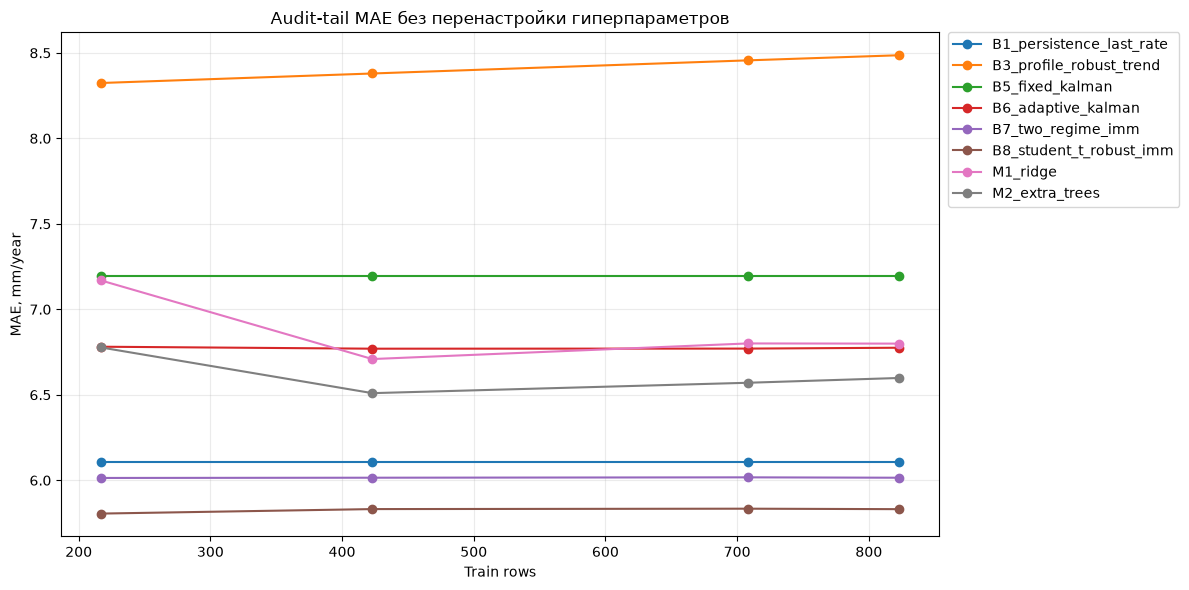

model_id,B1_persistence_last_rate,B3_profile_robust_trend,B5_fixed_kalman,B6_adaptive_kalman,B7_two_regime_imm,B8_student_t_robust_imm,M1_ridge,M2_extra_trees
training_rows,,,,,,,,
217,6.104,8.324,7.194,6.781,6.014,5.805,7.169,6.777
423,6.104,8.380,7.194,6.770,6.015,5.832,6.709,6.510
708,6.104,8.456,7.194,6.770,6.017,5.834,6.800,6.570
823,6.104,8.486,7.194,6.775,6.015,5.831,6.799,6.598


In [6]:
pivot = learning.pivot(index='training_rows', columns='model_id', values='mae')
ax = pivot.plot(marker='o', figsize=(12, 6))
ax.set(title='Audit-tail MAE без перенастройки гиперпараметров', xlabel='Train rows', ylabel='MAE, mm/year')
ax.grid(alpha=.25)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0), borderaxespad=0)
plt.tight_layout()
plt.show()
pivot.round(3)

## Формальные исключения

In [7]:
pd.DataFrame(methods['methods'])[['method_id', 'status', 'reason']]

,method_id,status,reason
0,ETS,NOT_ELIGIBLE_DATA_GEOMETRY,"Short, irregular and gapped point histories wo..."
1,ARIMA_ARIMAX,NOT_ELIGIBLE_DATA_GEOMETRY,Only 3-16 observations are available at issue ...
2,PROFILE_VAR,NOT_ELIGIBLE_DATA_GEOMETRY,Fourteen profiles and incomplete synchronous c...


In [8]:
assert report['historical_validation_loaded'] is False
assert report['current_t1_test_loaded'] is False
assert report['new_holdout_seen'] is False
assert report['protected_predecessors_match'] is True
assert validation['status'] == 'PASS' and validation['summary']['failed'] == 0
{'scope': report['scientific_scope'], 'claims_allowed': report['claim_boundary'], 'qa': validation['summary']}

{'scope': 'train_only_internal_research',
 'claims_allowed': 'no_final_model_quality_claim_without_new_future_or_external_holdout',
 'qa': {'checks': 20, 'failed': 0, 'passed': 20}}